<h1 style="color: #C0392B; text-align: center; font-family: 'Helvetica', sans-serif; border-bottom: 2px solid #C0392B; padding-bottom: 10px;">
    Les régions françaises métropolitaines les plus dynamiques : <br> analyse des déterminants de la création d’entreprises en France.
</h1>

<span style="color: #2E86C1;"> *Par Tom Proust, Tristan Czarnecki et Thomas Favant*
</span>.

<h1 id="intro" style="color:rgb(255, 255, 255); border-left: 10px solid rgb(255, 255, 255); padding-left: 15px;">Introduction</h1>
Derrière les moyennes nationales, la France cache de fortes disparités territoriales : tandis que l'Île-de-France et PACA affichent un dynamisme insolent, d'autres régions semblent peiner à renouveler leur tissu productif. **Quels sont les déterminants profonds de cette géographie entrepreneuriale ?**

À l’heure où la création d’entreprises est présentée comme le levier majeur du dynamisme économique, ce projet vise à :
1. **Mesurer** les écarts de création à l'échelle régionale (France métropolitaine).
2. **Identifier** les corrélations spatiales (Chômage, Diplômes).
3. **Modéliser** l'impact de ces variables via une approche économétrique rigoureuse.

<div class="alert alert-block alert-info">
<b>Note méthodologique :</b> Pour assurer la comparabilité des territoires, toutes nos analyses utilisent des taux normalisés (ex: créations pour 1 000 habitants).
</div>


Pourquoi certaines régions françaises voient-elles naître beaucoup plus d’entreprises que d’autres ? À l’heure où la création d’entreprises est souvent présentée comme un levier majeur de dynamisme économique et territorial, nous avons cherché à mesurer, comparer et expliquer ces écarts à l’échelle régionale.

Pour cela, nous exploitons plusieurs jeux de données open data publics afin d’analyser la création d’entreprises au sens large, sans distinction de taille ou de statut juridique. Cette approche permet de capter l’ensemble du phénomène entrepreneurial et d’en suivre l’évolution dans le temps.

Pour simplifier la récupération des données et avoir une précision maximale, nous avons réduit l'étude à la France métropolitaine.

Ce travail s’inscrit dans le cadre du cours Python pour la Data Science (ENSAE Paris) et respecte pleinement ses attendus. Il s’articule autour de trois axes complémentaires :

- récupération et traitement de données multi-sources ;

- analyse statistique descriptive et visualisation ;

- modélisation explicative et prédictive.

L’ensemble du projet est conçu dans un souci de reproductibilité, de clarté méthodologique et de synthèse des résultats.

### Installation des bibliothèques

In [1]:
# --- préfiguration technique ---
#################################

# mise en page
import warnings
warnings.filterwarnings('ignore') # nettoie le rendu final des avertissements inutiles

# imports nécessaires des bibliothèques nécessaires pour exécution du notebook 
# et essentielles aux fonctions du fichier 'mes_fonctions.py'
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm
import geopandas as gpd
from cartiflette import carti_download
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from cartiflette import carti_download
import numpy as np

# centralisation des chemins
from pathlib import Path
import sys
PROJECT_ROOT = Path(".").resolve()  # repo
sys.path.append(str(PROJECT_ROOT / "src"))  # rendre src/ importable

# style 
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14

This is an experimental version of cartiflette published on PyPi.
To use the latest stable version, you can install it directly from GitHub with the following command:
pip install git+https://github.com/inseeFrLab/cartiflette.git


<div style="background-color: #f8f9fa; padding: 20px; border-radius: 10px; border: 1px solid #dee2e6;">
    <h2 style="color: #34495E; margin-top: 0;">Sommaire détaillé</h2>
    <ul style="list-style-type: none; padding-left: 0;">
        <li><a href="#intro" style="color: #2E86C1; text-decoration: none; font-weight: bold;">0. Introduction & Problématique</a></li>
        <li style="margin-top: 10px;"><a href="#section1" style="color: #C0392B; text-decoration: none; font-weight: bold;">1. Constitution de la Base de Données</a>
            <ul style="color: #34495E;">
                <li>1.1 La variable epxliquée (Y) : le taux de création d'entreprises</li>
                <li>1.2 Construction des variables explicatives</li>
            </ul>
        </li>
        <li style="margin-top: 10px;"><a href="#section2" style="color: #C0392B; text-decoration: none; font-weight: bold;">2. Statistiques descriptives et analyse exploratoire</a>
            <ul style="color: #34495E;">
                <li>2.1 Analyse de l'hétérogénéité entrepreneuriale en France</li>
                <li>2.2 Analyse des variables explicatives et validation corrélations</li>
                <li>2.3 La France jacobine : expliquer la singularité de l'Île-de-France</li>
            </ul>
        </li>
        <li style="margin-top: 10px;"><a href="#section3" style="color: #C0392B; text-decoration: none; font-weight: bold;">3. Modélisation économétrique</a>
            <ul style="color: #34495E;">
                <li>3.1 Régression linéaire 1</li>
                <li>3.2 Régression linéaire 2</li>
                <li>3.3 Méthode Lasso</li>
                <li>3.2 Régression linéaire 3</li>
            </ul>
        </li>
        <li style="margin-top: 10px;"><a href="#conclusion" style="color: #2E86C1; text-decoration: none; font-weight: bold;">Conclusion & Ouverture</a></li>
    </ul>
</div>

<h1 id="section1" style="color: #C0392B; border-left: 10px solid #C0392B; padding-left: 15px;">1. Constitution de la base de données</h1>

<h2 style="color: #2E86C1;">1.1 La variable expliquée (Y) : le taux de création d'entreprises</h2>

Pour construire une variable cible, nous avons utilisé les données de publiées par l'INSEE, pour différentes enquêtes. La structure de ces données agrège plusieurs niveaux géographiques et plusieurs types de mesures, ce qui rend leur utilisation directe trompeuse et a nécessité. Un travail de réflexion méthodologique a donc été requis en amont de la récupération des données.

Une exploration initiale des fichiers bruts a mis en évidence des risques de double comptage et des incohérences lors des agrégations. Nous avons donc procédé à un filtrage strict et à une reconstruction contrôlée des agrégats régionaux. Pour obtenir un indicateur cohérent, nous avons construit un taux de création pour 1 000 habitants.

<div class="alert alert-block alert-info">
<b>Résumé méthodologie :</b> Nous filtrons les données INSEE, agrégeons les départements en régions, et normalisons le résultat par les estimations annuelles de population par régions. Nous obtenons un nombre d'entreprises créées par région par 1000 habitants.
</div>

### Étape 1 — Import et filtrage des données brutes

In [2]:
from mes_fonctions import load_insee_head

load_insee_head(
    PROJECT_ROOT / "Data" / "data_outdated" / "Fichier INSEE.csv"
)

,FREQ,GEO,GEO_OBJECT,LEGAL_FORM,SIDE_MEASURE,TIME_PERIOD,OBS_VALUE
0,A,64,DEP,_T,BURE,2014,6042
1,A,47,DEP,_T,BURE,2024,4151
2,A,36,DEP,_T,BURE,2023,1928
3,A,44,REG,_T,BURE,2015,33719
4,A,55,DEP,_T,BURE,2015,884


Le fichier INSEE est importé avec `pandas`. Il contient plusieurs niveaux géographiques et plusieurs types de mesures décrivant une même réalité économique. Afin d’éviter tout double comptage et de garantir une construction cohérente de la variable cible, les filtres suivants sont appliqués :

**Type de mesure**

On conserve uniquement les créations d’entreprises (unités légales) (SIDE_MEASURE == "BURE").
Le fichier INSEE regroupant également des cessations, des stocks ou des soldes, ce filtrage permet de définir une variable 
𝑌 économiquement homogène et interprétable.



**Niveau géographique**

On restreint l’analyse au niveau départemental (GEO_OBJECT == "DEP").
Le fichier contenant simultanément des données nationales, régionales et départementales, ce choix évite tout double comptage. Le niveau départemental constitue le niveau source le plus fin et permet de reconstruire de manière maîtrisée les agrégats régionaux par sommation.



**Période d’étude**

L’analyse est limitée aux années 2015 à 2024 afin de disposer d’une période récente et homogène, compatible avec les autres variables explicatives mobilisées dans le projet.



**Formes juridiques (si disponible)**

Lorsque l’information est présente, seules les observations correspondant au total toutes formes juridiques sont conservées. Cela permet d’éviter des redondances liées à la désagrégation par statut juridique.



**Typage des données**

La variable de valeur (OBS_VALUE) est convertie en numérique afin de permettre les agrégations et traitements statistiques ultérieurs.



À l’issue de ces filtrages, chaque observation correspond à une création d’entreprise unique, localisée à un département et une année donnés, fournissant une base propre et reproductible pour la construction de la variable régionale 𝑌.


### Étape 2 — Passage du niveau départemental au niveau régional

Les données INSEE étant fournies au niveau départemental, un changement d’échelle géographique est nécessaire.

- Un dictionnaire de correspondance département → région (codes INSEE) est défini explicitement.

- Chaque département est ainsi rattaché à sa région correspondante.

- Une vérification est effectuée afin de s’assurer qu’aucun département n’est perdu lors du mapping.

Les données sont ensuite agrégées par région et par année, en sommant le nombre de créations d’entreprises :

$$
Y_{r,t} = \sum_{d \in r} Créations_{d,t}
$$

où 𝑑 désigne les départements appartenant à la région 𝑟.

Le résultat est un tableau structuré :
- code_region
- TIME_PERIOD (année)
- nb_creations

In [3]:
from mes_fonctions import build_y_insee_region_year

Y = build_y_insee_region_year(
    PROJECT_ROOT / "Data" / "data_outdated" / "Fichier INSEE.csv"
)

Y.head()

,code_region,TIME_PERIOD,nb_creations
0,11,2015,145628
1,11,2016,165621
2,11,2017,184150
3,11,2018,215995
4,11,2019,246394


### Étape 3 — Nettoyage et enrichissement du fichier final

Afin de rendre les données plus lisibles et directement exploitables pour l’analyse et la visualisation :

- Les noms officiels des régions sont ajoutés.

- Un code court (IDF, AURA, PACA, etc.) est créé pour faciliter les graphiques.

- Les observations sont triées par région et par année.

Le fichier final est exporté au format CSV avec encodage UTF-8.

In [4]:
from mes_fonctions import clean_y_insee_region_year

Y_clean = clean_y_insee_region_year(Y)
Y_clean.head()

,code_region,TIME_PERIOD,nb_creations,nom_region,code_court
0,11,2015,145628,Île-de-France,IDF
1,11,2016,165621,Île-de-France,IDF
2,11,2017,184150,Île-de-France,IDF
3,11,2018,215995,Île-de-France,IDF
4,11,2019,246394,Île-de-France,IDF


### Étape 4 : pondérer par la population

La variable cible initiale correspond au nombre de créations d’entreprises par région. Or, ce volume dépend mécaniquement de la taille de la population : une région plus peuplée crée davantage d’entreprises, même à dynamisme entrepreneurial identique. Comparer les régions à partir du nombre brut de créations introduirait donc un biais de taille.

Pour supprimer cet effet, on normalise le nombre de créations par la population régionale. On construit ainsi un taux de création d’entreprises pour 1 000 habitants, qui mesure l’intensité de la création entrepreneuriale indépendamment de la taille de la région. Cette transformation permet de rendre les régions comparables entre elles et fournit une variable cible plus pertinente pour l’analyse descriptive et la modélisation.

In [5]:
from mes_fonctions import construire_Y_taux_creation, afficher_top_bottom

# chemins 
path_creation = "data/Variables explicatives/Variable_Y.csv"
path_pop = "data/Variables explicatives/population_par_region_annee.csv"

out_panel = None
out_avg = None

merged_df, avg_df = construire_Y_taux_creation(
    path_creation_csv=path_creation,
    path_population_csv=path_pop,
    out_path_panel=out_panel,
    out_path_avg=out_avg,
    facteur=1000,
    arrondi=2,
)

# Lisibilité : renommer pour l'affichage
avg_affichage = avg_df.rename(columns={
    "region_nom": "Region",
    "creations_per_1000": "Création moyenne d'entreprise par an (2015–2025) pour 1 000 habitants"
})

display(merged_df.head())
display(avg_affichage.head())

# Top / bottom 3
afficher_top_bottom(avg_df, col_region="region_nom", col_val="creations_per_1000", k=3)


,code_region,TIME_PERIOD,nb_creations,region_nom,code_court,population,creations_per_1000
0,11,2015,145628,Île-de-France,IDF,1.208214e+07,12.05
1,11,2016,165621,Île-de-France,IDF,1.211713e+07,13.67
2,11,2017,184150,Île-de-France,IDF,1.217488e+07,15.13
3,11,2018,215995,Île-de-France,IDF,1.221345e+07,17.69
4,11,2019,246394,Île-de-France,IDF,1.226254e+07,20.09


,Region,Création moyenne d'entreprise par an (2015–2025) pour 1 000 habitants
0,Auvergne-Rhône-Alpes,12.67
1,Bourgogne-Franche-Comté,9.17
2,Bretagne,9.25
3,Centre-Val de Loire,9.24
4,Corse,14.97


--- Les 3 plus faibles ---
                region_nom  creations_per_1000
7                Normandie                8.76
6          Hauts-de-France                8.89
1  Bourgogne-Franche-Comté                9.17

--- Les 3 plus élevés ---
                    region_nom  creations_per_1000
4                        Corse               14.97
11  Provence-Alpes-Côte d'Azur               16.67
12               Île-de-France               19.46


<h2 style="color: #2E86C1;">1.2 Construction des variables explicatives</h2>

Nous avons construit ou simplement récupéré les variables suivantes pour expliquer le dynamisme entrepreneurial régional: 
- Taux de chômage
- Taux de diplômés BAC+5 et plus (choix méthodologique)
- Taux de variation démographique
- Salaires moyens en équivalent temps plein
- Densité de population

<h3 style="color: #2E86C1;">1.2.1 Exemple de construction d'une variable explicative : population par région</h3>


#### Étape 1 — Chargement des données brutes de population (INSEE)

La première étape consiste à charger le fichier INSEE contenant les estimations de population. Ce fichier est utilisé sans transformation immédiate, afin de conserver l’intégralité de l’information disponible (différents niveaux géographiques, tranches d’âge, sexes, années). Cette approche permet de vérifier la structure du jeu de données, d’identifier les colonnes pertinentes et d’éviter toute perte d’information prématurée. Le chargement séparé des données brutes facilite également le débogage et garantit la reproductibilité du pipeline.

In [6]:
#Fichier INSEE importé 

from mes_fonctions import load_population_region_year

pop_raw = load_population_region_year(
    PROJECT_ROOT / "Data" / "data_outdated" / "DS_ESTIMATION_POPULATION_data.csv"
)

pop_raw.head()


,GEO,GEO_OBJECT,SEX,AGE,EP_MEASURE,OBS_STATUS_FR,TIME_PERIOD,OBS_VALUE
0,78,DEP,M,Y50T54,POP,D,2007,44919
1,85,DEP,M,Y60T64,POP,D,2007,15680
2,82,DEP,F,Y15T19,POP,D,2007,6516
3,79,DEP,_T,Y25T29,POP,D,2007,19285
4,62,DEP,F,Y_LT5,POP,D,2007,47222


#### Étape 2 — Construction du mapping géographique (code région → nom de région)

Les données INSEE reposent sur des codes géographiques (ex. REG-01) qui ne sont pas directement exploitables pour l’analyse ou la visualisation. Une étape intermédiaire consiste donc à construire un dictionnaire de correspondance entre ces codes et les noms des régions françaises. Cette opération s’appuie sur un fichier de référence officiel INSEE. Le mapping ainsi obtenu permet d’enrichir les données de population avec des libellés explicites, tout en assurant une cohérence géographique entre les différentes sources mobilisées dans le projet.

In [7]:
from mes_fonctions import build_region_name_mapping

mapping_region = build_region_name_mapping(
        PROJECT_ROOT / "Data" / "data_outdated" / "Liste de codes du dataset GEO (4).csv"
)

# aperçu (10-15 premières entrées)
list(mapping_region.items())[10:15]


[('44', 'Grand Est'),
 ('52', 'Pays de la Loire'),
 ('53', 'Bretagne'),
 ('75', 'Nouvelle-Aquitaine'),
 ('76', 'Occitanie')]

#### Étape 3 — Filtrage, agrégation et construction des variables démographiques

Dans cette étape finale, les données sont restreintes aux régions et à la période d’étude retenue. Seules les observations correspondant à la population totale (tous âges, tous sexes) sont conservées afin d’obtenir une mesure cohérente de la population régionale.

Les données sont ensuite agrégées pour produire une variable population par région et par année. À partir de cette variable, des indicateurs complémentaires sont construits, notamment la variation annuelle de population (en pourcentage) et la densité de population, obtenue à partir des superficies régionales. Cette étape aboutit à un jeu de données synthétique, directement exploitable comme variable explicative dans l’analyse économétrique.

In [8]:
from mes_fonctions import build_population_region_year

pop = build_population_region_year(pop_raw, mapping_region, year_min=2014, year_max=2025)
pop.head()


,TIME_PERIOD,region_nom,population,pop_prev,variation_population_pourcentage,surface_km2,densite_population
0,2014,Auvergne-Rhône-Alpes,7.820966e+06,NaN,NaN,71134,109.95
1,2015,Auvergne-Rhône-Alpes,7.877698e+06,7.820966e+06,0.73,71134,110.74
2,2016,Auvergne-Rhône-Alpes,7.916889e+06,7.877698e+06,0.50,71134,111.30
3,2017,Auvergne-Rhône-Alpes,7.948287e+06,7.916889e+06,0.40,71134,111.74
4,2018,Auvergne-Rhône-Alpes,7.994459e+06,7.948287e+06,0.58,71134,112.39


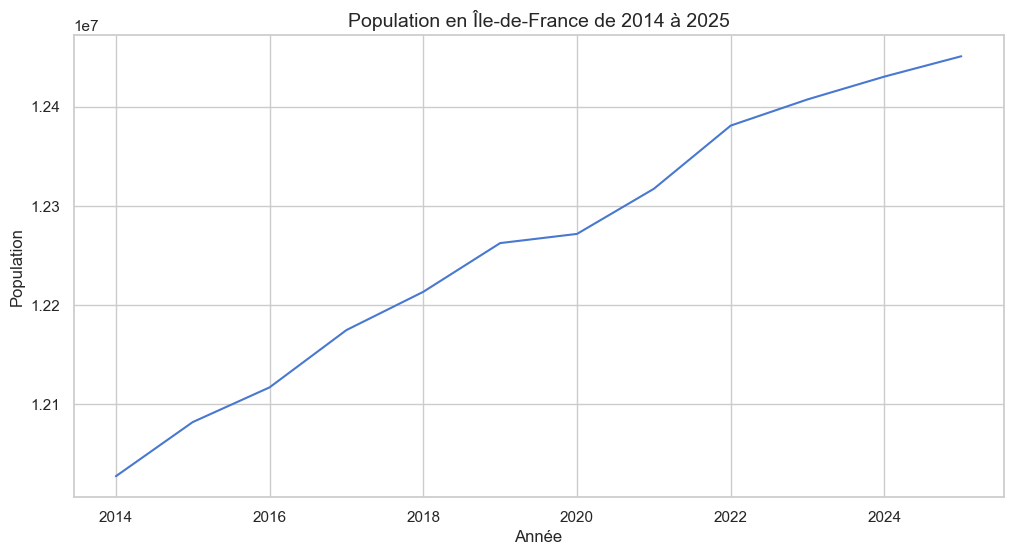

In [9]:
# Visualisation de l'évolution de la population en IDF

from mes_fonctions import plot_population_region

plot_population_region(pop, "Île-de-France")


<h3 style="color: #2E86C1;">1.2.2 Autres variables explicatives</h3>

Nous avons également récupéré les données des autres variables sur le site de l'INSEE, et avons mené des transformations similaires à l'aide de `pandas`.

Toutes les variables explciatives sont des taux pour ne pas afficher l'influence de la population 


<div class="alert alert-block alert-info">
<b>Note méthodologique :</b> 
Nous avons fait le choix de considérer qu’il n’existe pas de variation structurelle significative du niveau d’éducation par région sur la période 2015–2024. Le taux de diplômés du supérieur observé en 2022 est donc retenu comme proxy constant.
</div>

<div class="alert alert-block alert-info">
<b>Note dossiers :</b> 
- L'intégralité des transformations menées sur les données brutes se trouvent dans le sous-dossier "Extraction variables explicatives". Les données brutes se trouvent dans le dossier "data_outdated"
</div>

<h1 id="section2" style="color: #C0392B; border-left: 10px solid #C0392B; padding-left: 15px;">2. Statistiques descriptives et analyse exploratoire des dynamiques territoriales</h1>

Avant de quantifier les corrélations par l'économétrie, il est essentiel de mettre en lumière la géographie des disparités entrepreneuriales et d'avoir un regard préalable sur nos variables. Cette section vise à analyser la structure du dynamisme entrepreneurial français à travers trois angles:

1. **La Dimension Spatiale :** À l'aide de la bibliothèque `cartiflette`, nous cartographions nos variables afin d'observer leur répartition et de mettre en évidence d'éventuels inégalités ou déséquilibres régionaux
2. **La Structure Statistique :** L'analyse des distributions et des boîtes à moustaches (boxplots) nous permet de mesurer la dispersion de nos indicateurs et d'identifier les valeurs atypiques.
3. **Le Dualisme Territorial :** Nous explorons la fracture entre l'Île-de-France et la "Province" pour déterminer si le dynamisme observé est un phénomène national ou le résultat d'une concentration macrocéphale parisienne.

<div class="alert alert-block alert-success">
<b>Objectif :</b> Valider la pertinence de nos variables sur quelques exemples, et vérifier si les hypothèses de linéarité sont visuellement crédibles avant de lancer nos modèles de régression.
</div>

<h2 style="color: #2E86C1;">2.1. Analyse de l'hétérogénéité spatiale : une France entrepreneuriale disparate
</h2>

La carte ci-dessous illustre la répartition géographique du taux moyen de création d’entreprises sur la période 2015-2024.

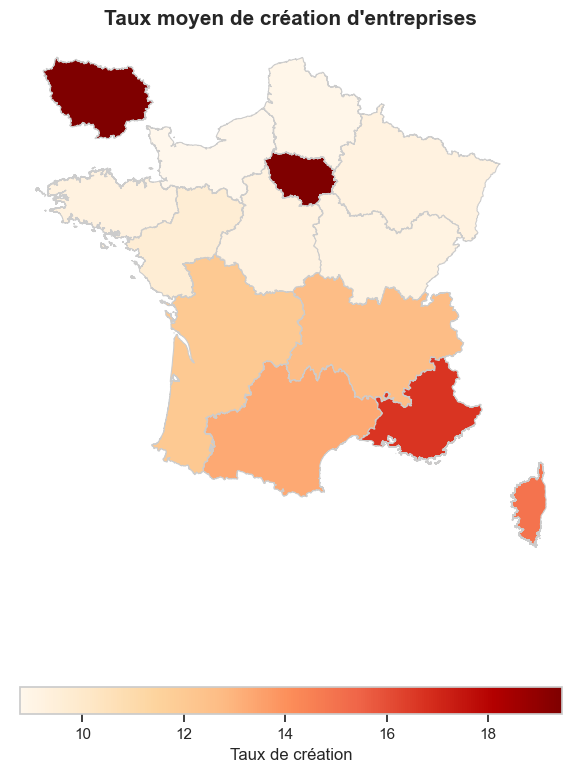

In [10]:
from mes_fonctions import carte_creations

regions = carti_download(
    values="France",
    crs=4326,
    borders="REGION",
    vectorfile_format="geojson",
    filter_by="FRANCE_ENTIERE_DROM_RAPPROCHES",
    source="EXPRESS-COG-CARTO-TERRITOIRE",
    year=2022,
)

carte_creations(
    regions_gdf=regions,
    path_creation="data/Variables explicatives/avg_creation_2015_2025.csv",
)

Celle-ci révèle de fortes disparités territoriales qui peuvent s'interpréter à travers plusieurs concepts de sociologie urbaine et de géographie économique.

**L'attrait métropolitain et l'héritage du modèle Jacobin** : La carte souligne d'abord la position hégémonique de l'Île-de-France (en rouge très foncé). Avec un taux de création dépassant les 16-18%, la région capitale concentre massivement les infrastructures, les sièges sociaux et les centres de décision. Cette configuration illustre la persistance d'une organisation territoriale très centralisée où la densité d'acteurs favorise mécaniquement des économies d'agglomération puissantes (visuellement: Paris, puis PACA - Marseille, Nice - et enfin Occitanie - Toulouse, Montpellier). Le statut de "cas particulier" pour l'Île-de-France au sein de la hiérarchie urbaine française fera l'objet d'un examen approfondi par la suite.

**Le dynamisme des façades maritimes et du couloir rhodanien** : On observe une dynamique en faveur de la façade Atlantique et l'arc méditerranéen (Nouvelle-Aquitaine, Occitanie, PACA, Auvergne-Rhône-Alpes). Ce phénomène témoigne d'un glissement des pôles d'activité vers des territoires bénéficiant d'une forte attractivité résidentielle. L'apport constant de populations extérieures, souvent qualifiées, alimente localement un vivier de projets qui renouvelle le tissu économique régional au-delà des centres industriels historiques.

**La fracture territoriale (Centre-Périphérie)** : À l'inverse, un axe de moindre dynamisme se dessine du Nord-Est (Grand-Est, Bourgogne-Franche-Comté) jusqu'au centre du pays. Ces régions, dont certaines subissent encore les mutations profondes de leurs anciens bassins productifs, affichent des taux de création plus modestes. Cette situation reflète des disparités de densité et une structure économique moins dynamique, où les écosystèmes d'accompagnement à la création d'entreprises sont souvent moins denses ou en cours de structuration.


<h2 style="color: #2E86C1;">2.2. Analyse des déterminants socio-économiques : exemple du chômage et du niveau d'éducation</h2>

Ces disparités spatiales semblent étroitement liées au profil social des territoires. Nous analysons dans cette sous-partie la répartition territoriale des niveaux de diplôme et des taux de chômage afin d'établir des corrélations visuelles avec le dynamisme entrepreneurial et de valider nos hypothèses de linéarité.

<h3 style="color: #2E86C1;">2.2.1. Taux de création d'entreprises et taux de chômage </h3>

#### Corrélation visuelle : cartographie

Les cartes ci-dessous mettent en regard la répartition géographique du taux moyen de création d’entreprises sur la période 2015-2024 et celle du taux de chômage.

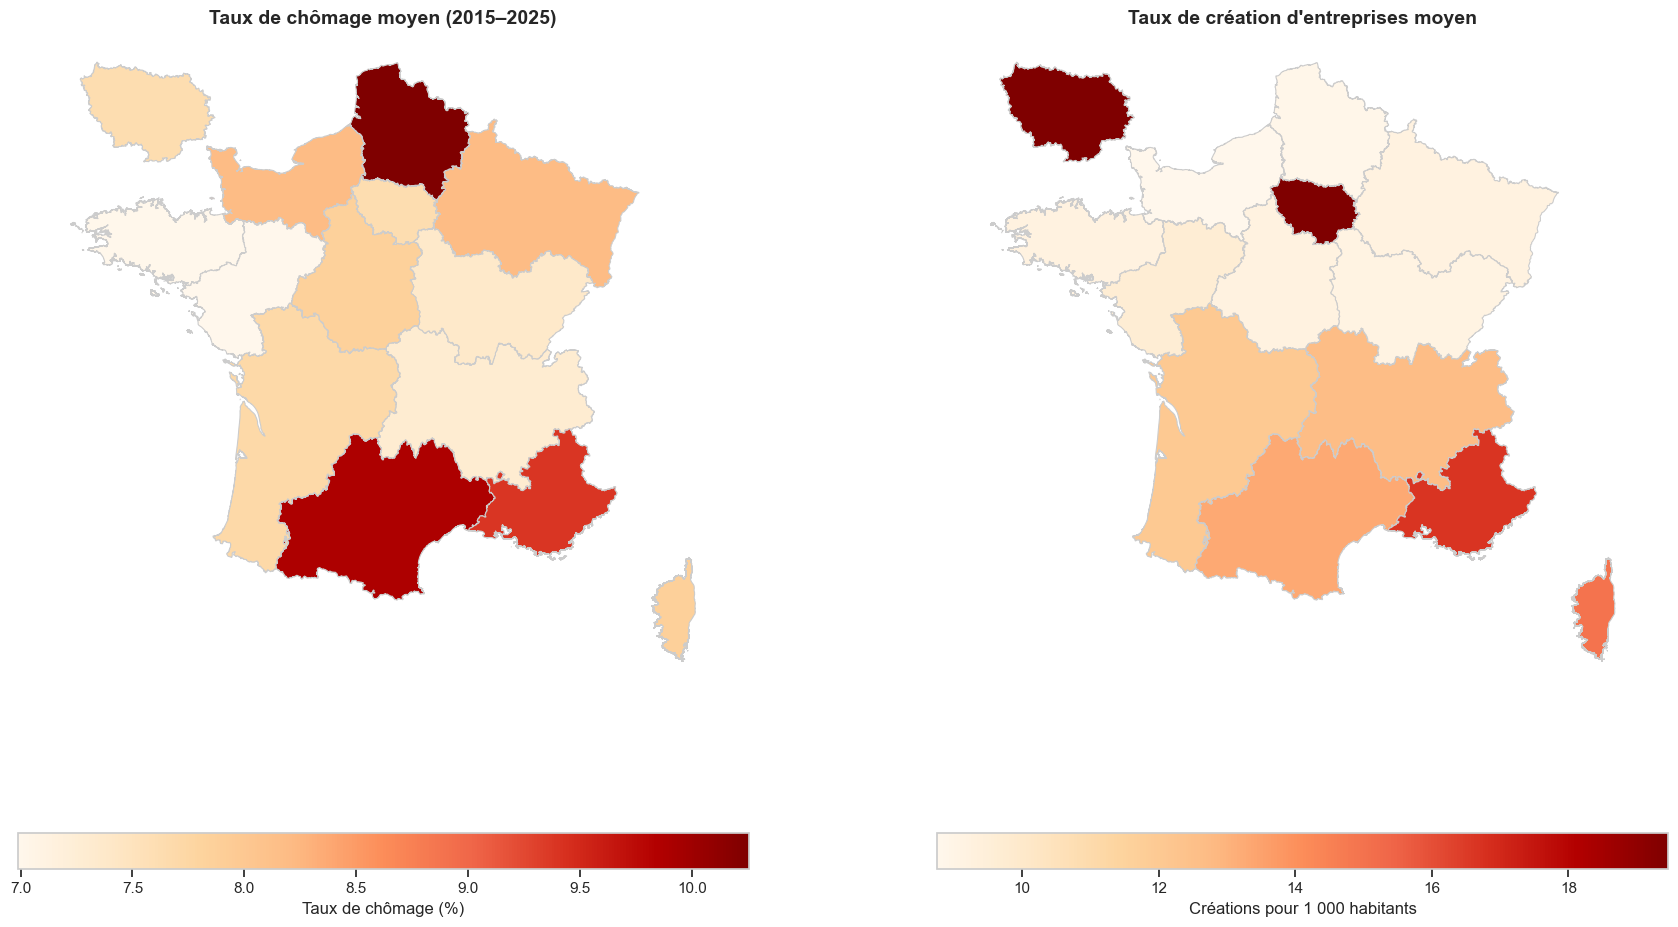

In [11]:
from mes_fonctions import carte_chomage_creation

regions = carti_download(
    values="France",
    crs=4326,
    borders="REGION",
    vectorfile_format="geojson",
    filter_by="FRANCE_ENTIERE_DROM_RAPPROCHES",
    source="EXPRESS-COG-CARTO-TERRITOIRE",
    year=2022,
)

carte_chomage_creation(
    regions_gdf=regions,
    path_chomage="data/Variables explicatives/chomage_format_long.csv",
    path_creation="data/Variables explicatives/avg_creation_2015_2025.csv",
)



**Interpétation** : La comparaison de celles-ci permet de tester visuellement l'hypothèse économique de l'effet d'attraction (l'économie saine attire la création). Ici, la précarité économique agit clairement comme un frein. Le chômage élevé ne "pousse" pas à la création, il l'inhibe, confirmant l'absence d'entrepreneuriat de nécessité massif.

Confirmation de la corrélation inverse dans le Nord : La région Hauts-de-France est le cas parfait de variation linéaire dans notre modèle.

**Nuance nécessaire** : Il y a un paradoxe des régions du Sud, facile à relever visuellement, qui nécessite de nuancer le modèle statistique global. Regardons l'Occitanie et la région PACA : Elles ont des taux de chômage élevés (Rouge foncé à gauche).Pourtant, elles ont aussi des taux de création élevés (Orange/Rouge à droite).

**Interprétation** : Cela suggère qu'un autre facteur compense l'effet négatif du chômage dans ces régions. Notre modèle de régression nous a donné la réponse : la Variation de la Population (coefficient +2.72). Le dynamisme démographique de ces régions (flux migratoires positifs) soutient la création d'entreprise malgré un chômage structurel élevé.

Il semble y avoir une corrélation négative entre chômage et création d'entreprise, qu'on va analyser dans une première regréssion.

#### Corrélation visuelle : graphique de regréssion

Le but est d'analyser la corrélation entre le taux de chômage et la création d'entreprises par 1000 habitants dans différentes régions et périodes. Pour cela, on écrit une fonction (dans `mes_fonction.py`), qui calcule le coefficient de corrélation de Pearson entre le taux de chômage et la création d'entreprises par 1000 habitants.

--- Analyse Statistique ---
Coefficient de corrélation (Pearson) : -0.35
Tendance : Inverse (Plus le chômage est haut, moins on crée).


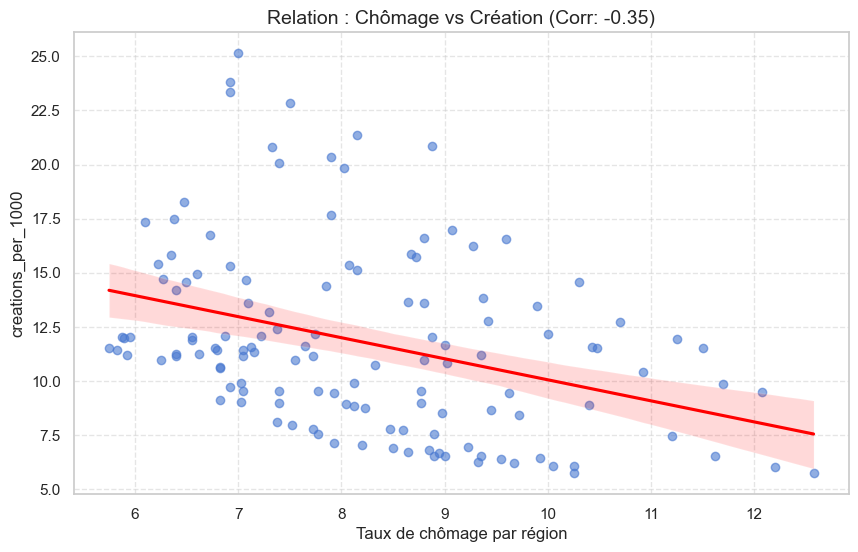

In [12]:
import pandas as pd
correlation_chomage_creation=pd.read_csv("data/Variables explicatives/correlation_chomage_creation.csv")

from mes_fonctions import analyser_relation_chomage_creation

analyser_relation_chomage_creation(correlation_chomage_creation)



**Analyse de la corrélation** : 

Le nuage de points ci-contre permet d'objectiver et de quantifier la relation inverse pressentie lors de l'observation des cartes. L'analyse de cette distribution révèle trois enseignements majeurs :

1. Une corrélation négative confirmant la nature "pro-cyclique" Avec un coefficient de corrélation de -0.35, la relation est inverse et modérément significative. La pente descendante de la droite de régression indique clairement que la bonne santé économique (faible chômage) est davantage corrélée à la création d'entreprises que la précarité. Hypothèse de repoussement écartée : Si le chômage était le moteur principal (création par survie), la pente serait positive. Hypothèse d'attraction validée : Les données corroborent une dynamique d'opportunité. Un marché de l'emploi sain (signe de dynamisme économique, confiance des ménages, accès au crédit facilité) constitue un terreau plus fertile pour l'entrepreneuriat.

2. Le chômage comme facteur limitant (plafond de verre). L'analyse visuelle de la distribution met en évidence une contrainte forte : au-delà de 10 % de chômage, le taux de création ne décolle jamais (aucun point supérieur à 15 créations pour 1000 habitants). Un contexte économique dégradé semble donc agir comme un frein structurel, "interdisant" les dynamiques entrepreneuriales fortes.

3. La condition nécessaire, mais non suffisante La partie gauche du graphique (chômage faible, entre 6 et 8 %) montre une très forte disparité. Si c'est dans cette zone que l'on trouve les records de création (> 20), on y trouve aussi des taux beaucoup plus modestes. Conclusion : Un faible chômage est une condition nécessaire pour permettre une forte création d'entreprises, mais elle n'est pas suffisante. D'autres déterminants locaux (attractivité touristique, métropolisation, politiques locales) interviennent pour transformer ce potentiel économique en création effective.

<h3 style="color: #2E86C1;">2.2.2. Taux de création d'entreprises et niveaux de diplômes </h3>

#### Corrélation visuelle : cartographie

Les cartes ci-dessous mettent en regard la répartition géographique du taux moyen de création d’entreprises (2015-2025) et celle du niveau de formation. Le pourcentage de diplômés du supérieur (Bac+5 et plus) est retenu comme indicateur du capital humain régional.

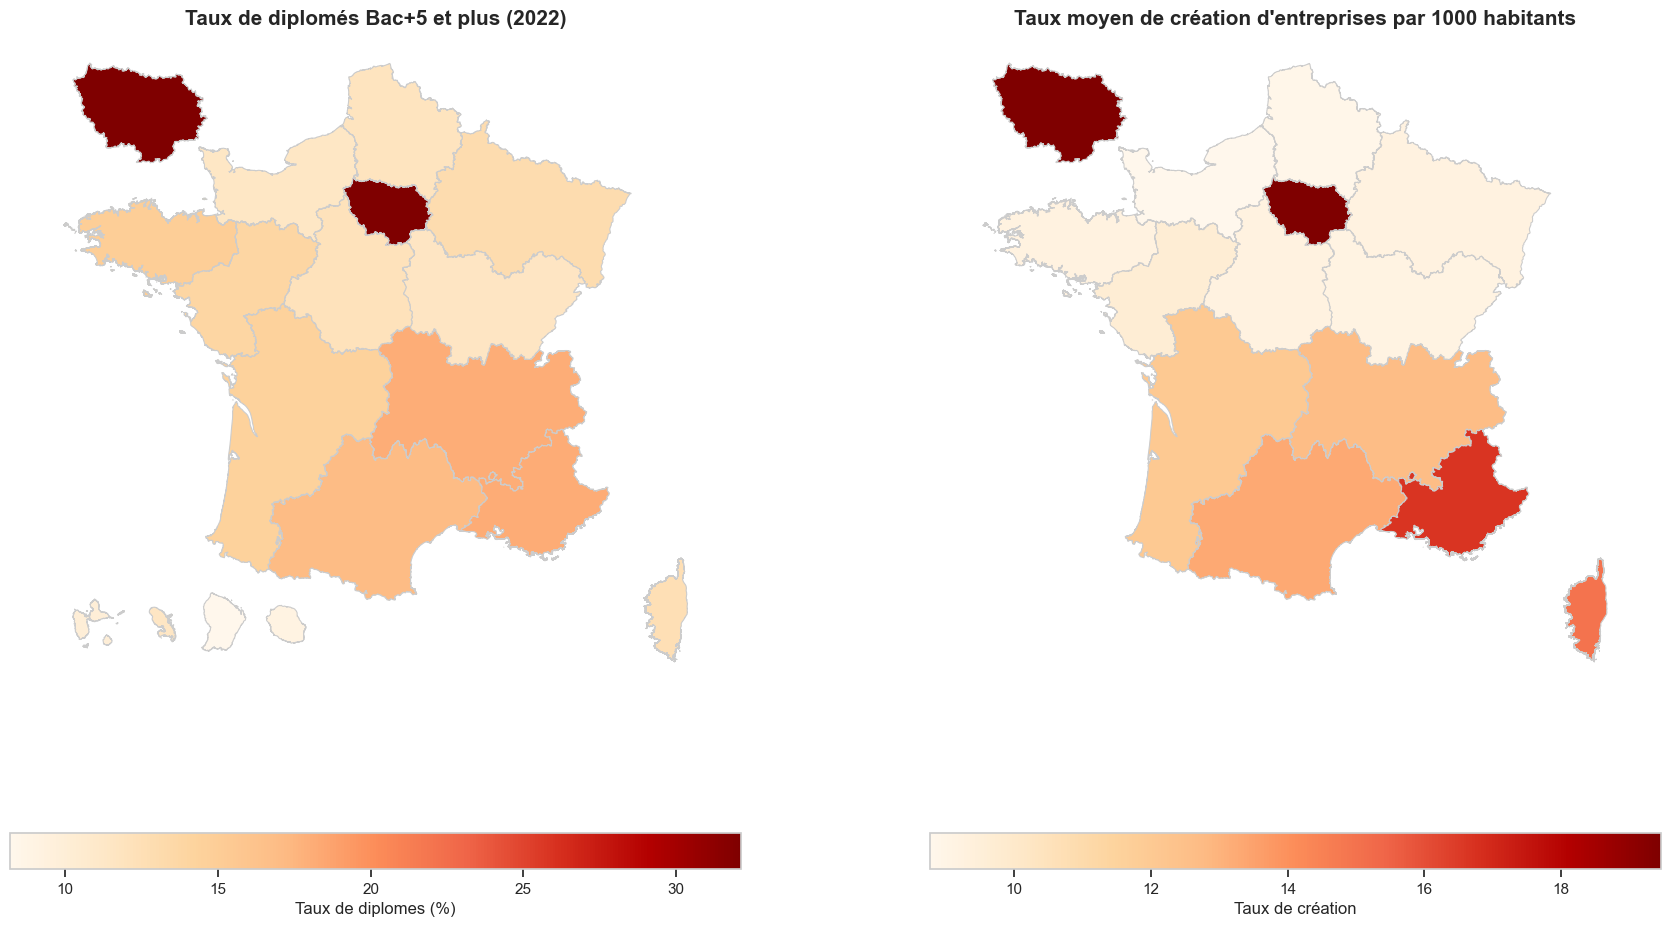

In [13]:
from mes_fonctions import carte_educ1

regions = carti_download(
    values="France",
    crs=4326,
    borders="REGION",
    vectorfile_format="geojson",
    filter_by="FRANCE_ENTIERE_DROM_RAPPROCHES",
    source="EXPRESS-COG-CARTO-TERRITOIRE",
    year=2022,
)

carte_educ1(
    regions_gdf=regions,
    path_educ="data/Variables explicatives/diplome_region.csv",
    path_creation="data/Variables explicatives/avg_creation_2015_2025.csv",
)

On observe un lien entre les régions caractérisées par une forte proportion de diplômés du supérieur et celles présentant des taux élevés de création d’entreprises, en particulier pour l'Île-de-France. Cette corrélation visuelle reste toutefois insuffisante, et l’indicateur « Bac+5 et plus » peut paraître arbitraire.

En effet, le choix de cette variable repose sur l’idée que les niveaux de formation les plus élevés sont davantage associés aux réseaux professionnels et à la capacité à mobiliser des opportunités entrepreneuriales. Il s’agit toutefois d’un indicateur partiel, retenu ici à des fins exploratoires.

Afin de dépasser le recours à un indicateur unique de niveau de formation, nous avons donc construit, à titre exploratoire, un indice synthétique d’éducation à partir d’une analyse en composantes principales (ACP) des trois catégories de diplômes disponibles : aucun diplôme, du Bac au Bac+5, et Bac+5 et plus.


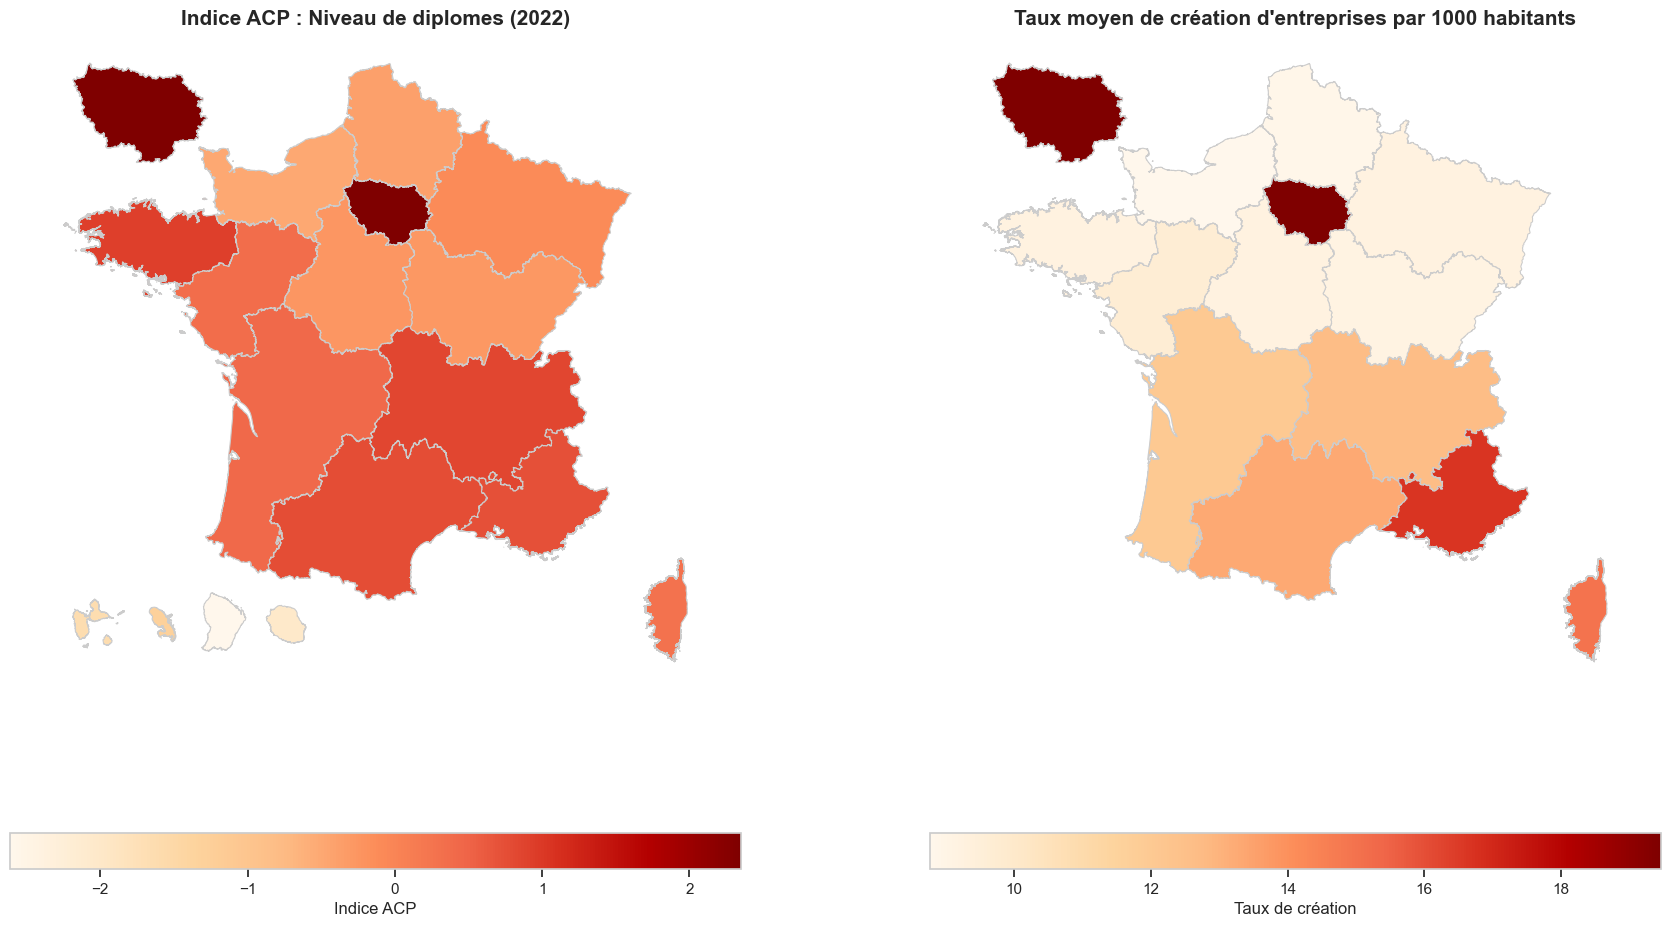

In [14]:
from mes_fonctions import carte_educ2

regions = carti_download(
    values="France",
    crs=4326,
    borders="REGION",
    vectorfile_format="geojson",
    filter_by="FRANCE_ENTIERE_DROM_RAPPROCHES",
    source="EXPRESS-COG-CARTO-TERRITOIRE",
    year=2022,
)

carte_educ2(
    regions_gdf=regions,
    path_educ="data/Variables explicatives/diplome_region.csv",
    path_creation="data/Variables explicatives/avg_creation_2015_2025.csv",
)

La cartographie de cet indice synthétique dilue les ordres de grandeur observés précédemment. Dans la mesure où cet indicateur reste moins directement interprétable et n’apporte pas d’information décisive supplémentaire, on conserve par la suite le pourcentage de diplômés du supérieur (Bac+5 et plus) comme variable explicative principale dans les analyses de régression.

#### Statistiques descriptives sur le niveau d'éducation


Le graphique ci-dessous représente la distribution de la part de diplômés du supérieur par région en France métropolitaine.

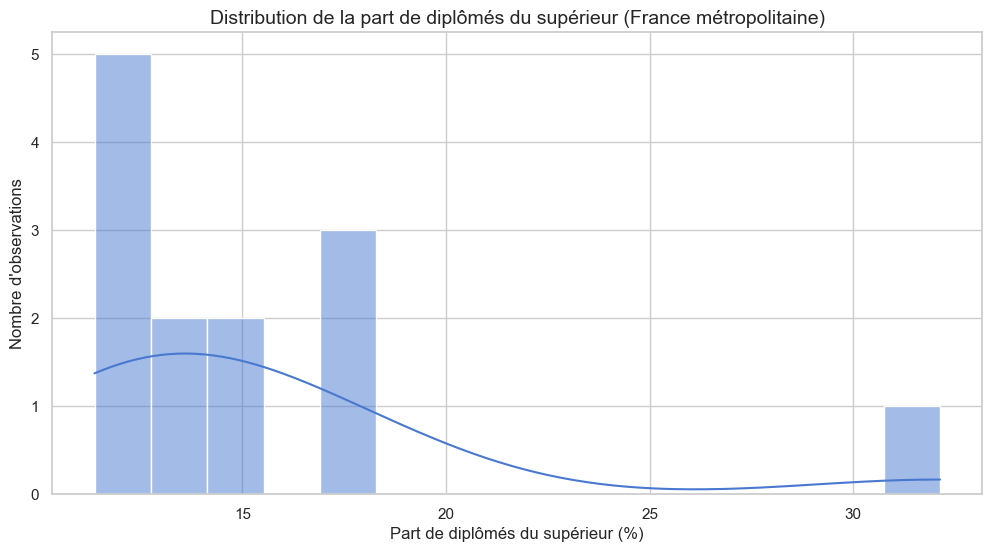

In [15]:
import pandas as pd

# Chargement du fichier diplôme
df_diplome = pd.read_csv("data/Variables explicatives/diplome_region.csv")

dom_tom = [
    "Guadeloupe",
    "Martinique",
    "Guyane",
    "La Réunion",
    "Mayotte"
]


df_diplome_metropole = df_diplome[
    ~df_diplome["region_nom"].isin(dom_tom)
].copy()

import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(
    data=df_diplome_metropole,
    x="Pourcentage_diplomes_superieur",
    bins=15,
    kde=True
)

plt.title("Distribution de la part de diplômés du supérieur (France métropolitaine)")
plt.xlabel("Part de diplômés du supérieur (%)")
plt.ylabel("Nombre d'observations")
plt.show()


La distribution de la part de diplômés du supérieur en France métropolitaine est asymétrique à droite. Comme vu précédemment, la majorité des régions se situe dans une fourchette relativement resserrée (autour de 12–18 %), tandis que l'Île-de-France, se distingue nettement. 

Cela met en évidence une forte hétérogénéité territoriale du capital humain, justifiant l’intérêt d’utiliser cette variable pour expliquer les différences de dynamisme entrepreneurial entre régions.

**Boxplot**


*Création du DataFrame d’analyse*

On fusionne
- Le taux de création d’entreprises (région × année),
- Le taux de diplômés du supérieur (région, observé en 2022),
En faisant l’hypothèse que le niveau de diplôme est structurellement stable sur 2015–2024. Le merge se fait donc uniquement sur la région, et non sur l’année.

La difficulté clé réside dans le fait que les deux bases n’ont pas la même dimension temporelle : TIME_PERIOD existe pour la création, mais il est absent pour le diplôme. Il faut donc identifier cette incompatibilité, puis la résoudre par une hypothèse économique explicite (constance du capital humain).


In [16]:
import pandas as pd

creation = pd.read_csv("data/Variables explicatives/creation_per_1000.csv")
diplome = pd.read_csv("data/Variables explicatives/diplome_region.csv")

# enlever DOM-TOM
dom_tom = ["Guadeloupe", "Martinique", "Guyane", "La Réunion", "Mayotte"]
creation = creation[~creation["region_nom"].isin(dom_tom)].copy()
diplome  = diplome[~diplome["region_nom"].isin(dom_tom)].copy()

# merge sur la région uniquement (diplôme 2022 appliqué à toutes les années)
df = creation.merge(diplome[["region_nom", "Pourcentage_diplomes_superieur"]],
                    on="region_nom", how="inner")

df.head()

,code_region,TIME_PERIOD,nb_creations,region_nom,code_court,population,creations_per_1000,Pourcentage_diplomes_superieur
0,11,2015,145628,Île-de-France,IDF,1.208214e+07,12.05,32.13
1,11,2016,165621,Île-de-France,IDF,1.211713e+07,13.67,32.13
2,11,2017,184150,Île-de-France,IDF,1.217488e+07,15.13,32.13
3,11,2018,215995,Île-de-France,IDF,1.221345e+07,17.69,32.13
4,11,2019,246394,Île-de-France,IDF,1.226254e+07,20.09,32.13


**Tracé des boxplots**

On classe les régions en quartiles de diplomation, puis on compare le taux de création d’entreprises entre ces groupes à l’aide de boxplots.

La difficulté réside dans le fait de passer d’une variable continue (diplôme) à des groupes comparables.

On interpéte ensuite correctement médianes, dispersion et recouvrement.

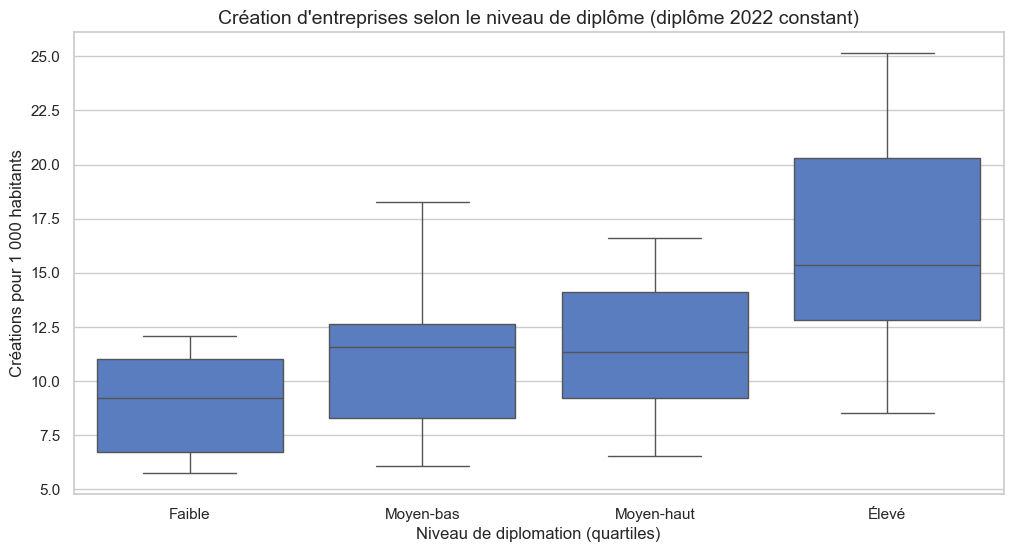

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

df["diplome_q"] = pd.qcut(
    df["Pourcentage_diplomes_superieur"],
    q=4,
    labels=["Faible", "Moyen-bas", "Moyen-haut", "Élevé"]
)

sns.boxplot(data=df, x="diplome_q", y="creations_per_1000")
plt.title("Création d'entreprises selon le niveau de diplôme (diplôme 2022 constant)")
plt.xlabel("Niveau de diplomation (quartiles)")
plt.ylabel("Créations pour 1 000 habitants")
plt.show()



Les boxplots montrent que les régions les plus diplômées présentent en médiane un taux de création d’entreprises plus élevé. Malgré un recouvrement entre groupes, on observe un gradient clair suggérant un lien positif entre capital humain et dynamisme entrepreneurial, sans préjuger d’un lien causal.

<h3 style="color: #2E86C1;">2.2.3. Autres variables explicatives </h3>

L'effet des autres variables explicatives aurait également pu être étudié avec les méthodes présentés ci-dessus.
Pour éviter la répétition, nous commenterons leur effet dans la partie Modélisation

<h2 style="color: #2E86C1;">2.3. La France jacobine : expliquer la singularité parisienne</h2>

### Modèle économétrique ###

Afin d’identifier un éventuel effet spécifique à l’Île-de-France sur la création
d’entreprises, nous estimons le modèle linéaire suivant :

$$TauxCréation_i = \beta_0 + \beta_1 \cdot Diplôme + \beta_2 \cdot Chômage + \beta_3 \cdot VariationPop + \beta_4 \cdot DensitéPop + \beta_5 \cdot IDF \epsilon_i$$

où :
- IDF est une variable indicatrice prenant la valeur 1 pour l’Île-de-France et 0 sinon ;
- les autres variables contrôlent pour des facteurs économiques et démographiques
  classiquement associés à la dynamique entrepreneuriale.

Le coefficient $$\beta_5$$ mesure ainsi un **effet résiduel propre à l’Île-de-France**, toutes choses égales par ailleurs.

In [29]:
from mes_fonctions import build_regression0_csv

regression0 = build_regression0_csv(
    path_diplome="data/Variables explicatives/diplome_region.csv",
    path_chomage="data/Variables explicatives/chomage_format_long.csv",
    path_creation_per_1000="data/Variables explicatives/creation_per_1000.csv",
    path_population="data/Variables explicatives/population_par_region_annee.csv",
    path_salaires="data/Variables explicatives/salaires_EQTP.csv",
    out_csv_path="data/Variables explicatives/regression0.csv",
    drop_domtom=True,
)

df = regression0
df['idf_sol'] = (df['region_nom'] == 'Île-de-France').astype(int)


# 1. définition  variables + ajout constante
y = df['creations_per_1000']
X = df[
    ['Taux de chômage par région', 'Pourcentage_diplomes_superieur', 'variation_population_pourcentage', 'densité de population', 'idf_sol']
]
X = sm.add_constant(X)

# 3. Création et ajustement du modèle (MCO = Moindres Carrés Ordinaires)
model = sm.OLS(y, X)
results = model.fit()

# 4. Affichage du rapport complet
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:     creations_per_1000   R-squared:                       0.585
Model:                            OLS   Adj. R-squared:                  0.566
Method:                 Least Squares   F-statistic:                     31.27
Date:                Wed, 24 Dec 2025   Prob (F-statistic):           9.54e-20
Time:                        18:03:29   Log-Likelihood:                -279.80
No. Observations:                 117   AIC:                             571.6
Df Residuals:                     111   BIC:                             588.2
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

### Analyse des résultats ###

Les résultats de l’estimation indiquent que le coefficient associé à la variable indicatrice « Île-de-France » n’est pas statistiquement significatif. Bien que son signe soit négatif, l’intervalle de confiance à 95 % inclut largement zéro, ce qui empêche de conclure à l’existence d’un effet propre de cette région sur la création d’entreprises, toutes choses égales par ailleurs.

Cela suggère que la singularité observée de cette région en matière de création d’entreprises s’explique principalement
par ses caractéristiques économiques et démographiques mesurables, plutôt que par un effet institutionnel ou symbolique autonome.

Autrement dit, une fois les variables contrôlée, l’Île-de-France ne se distingue plus statistiquement des autres régions. Ce résultat invite à relativiser l’hypothèse d’un effet propre lié à la centralisation administrative ou au pouvoir symbolique
parisien, au profit d’une lecture fondée sur les mécanismes classiques d’agglomération et de composition socio-économique.

<h1 id="section3" style="color: #C0392B; border-left: 10px solid #C0392B; padding-left: 15px;">3. Modélisation économétrique</h1>

<h2 style="color: #2E86C1;">3.1. Régression linéaire 1</h2>

Afin d'identifier les facteurs influençant le dynamisme entrepreneurial des régions, nous procédons à une régression linéaire multiple (Méthode des Moindres Carrés Ordinaires - OLS).Le modèle économétrique testé est le suivant :$$TauxCréation_i = \beta_0 + \beta_1 \cdot Diplôme + \beta_2 \cdot Chômage + \beta_3 \cdot VariationPop + \beta_4 \cdot Densité + \epsilon_i$$

Choix des variables :Variable expliquée ($Y$) : Le taux de création d'entreprises (pour 1000 habitants), indicateur direct du dynamisme entrepreneurial.

**Variables explicatives ($X$)** :
- **Capital Humain** : Le pourcentage de diplômés du supérieur (proxy du niveau de qualification de la région).
- **Conjoncture Économique** : Le taux de chômage (pour tester l'effet "push" vs "pull").
- **Dynamisme Démographique** : La variation de la population (attractivité du territoire)
- **Agglomération** : La densité de population (effets de métropolisation).


<div class="alert alert-block alert-info">
<b>Hypothèse de modélisation :</b> 
Nous utilisons une approche "Pooled OLS" sur l'ensemble de notre panel (130 observations : 13 régions x 10 années). Cette méthode permet d'inclure des variables structurelles invariantes sur la période étudiée (comme le niveau de diplôme, fixé ici à son niveau de 2022) et de mesurer leur impact global sur les disparités inter-régionales.</div>



Pour créer le dataset contenant la variable explicative et les variables explicatives, nous l'avons fait dans le notebook "regression.ipynb" pour vérifier que les merges des datasets de nos variables explicatives s'effectuaient correctement'. Le dataset s'appelle 'regression1'.

Les données sur les diplômes des français n'étaient disponibles qu'en 2022 sur l'INSEE donc nous avons fait une **hypothèse de stabilité** :
Le niveau d'éducation d'une région change très lentement. On peut raisonnablement supposer que si une région est très diplômée en 2022, elle l'était aussi (relativement aux autres) en 2015.

In [30]:
from mes_fonctions import build_regression1_csv

# On crée la table de régression 

regression1 = build_regression1_csv(
    path_diplome="data/Variables explicatives/diplome_region.csv",
    path_chomage="data/Variables explicatives/chomage_format_long.csv",
    path_creation_per_1000="data/Variables explicatives/creation_per_1000.csv",
    path_population="data/Variables explicatives/population_par_region_annee.csv",
    out_csv_path="data/Variables explicatives/regression1.csv",
    drop_domtom=True,
)


In [31]:
y = regression1["creations_per_1000"]
X = sm.add_constant(regression1[
    [
        "Taux de chômage par région",
        "Pourcentage_diplomes_superieur",
        "variation_population_pourcentage",
        "densité de population",
    ]
])

results1 = sm.OLS(y, X).fit()
print(results1.summary())


                            OLS Regression Results                            
Dep. Variable:     creations_per_1000   R-squared:                       0.577
Model:                            OLS   Adj. R-squared:                  0.563
Method:                 Least Squares   F-statistic:                     42.58
Date:                Wed, 24 Dec 2025   Prob (F-statistic):           1.70e-22
Time:                        18:06:30   Log-Likelihood:                -316.14
No. Observations:                 130   AIC:                             642.3
Df Residuals:                     125   BIC:                             656.6
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

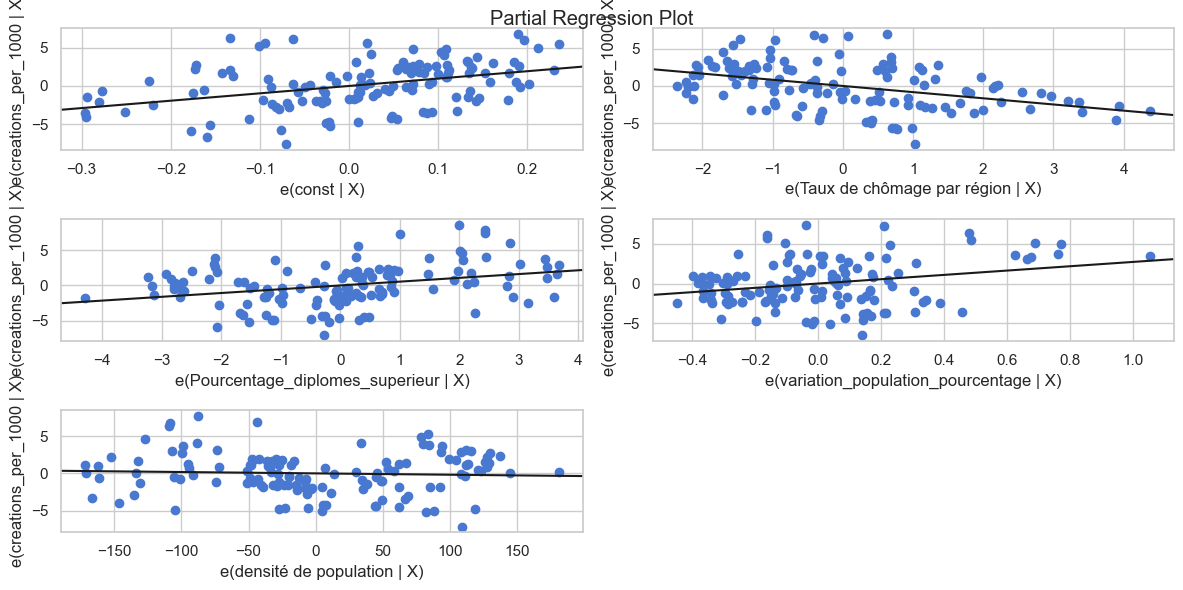

In [21]:
# Visualisation de l'effet des variables (non causal)

import statsmodels.api as sm
fig = sm.graphics.plot_partregress_grid(results1)


<h3 style="color: #2E86C1;">3.1.1. Performance globale du modèle </h3>

**Qualité de l'ajustement ($R^2$)** : 
Le $R^2$ est de 0.577. Cela signifie que notre modèle explique 57,7 % de la variance du taux de création d'entreprises. 
Pour des données socio-économiques, c'est un score élevé, indiquant que les variables choisies sont très pertinentes pour expliquer le phénomène.Significativité globale (F-statistic) : La probabilité associée (Prob F-statistic: $1.70e-22$) est quasi nulle, ce qui confirme que le modèle dans son ensemble est statistiquement valide.


<h3 style="color: #2E86C1;">3.1.2. Analyse des déterminants (Variables significatives) </h3>

Trois variables ont un impact statistiquement significatif (P-value < 0.05) sur la création d'entreprise :
- **Le Taux de Chômage** (Coef: -0.82, P<0.001) :Impact : Il existe une relation négative forte. Toutes choses égales par ailleurs, une augmentation de 1 point du taux de chômage entraîne une baisse de 0.82 point du taux de création.Interprétation : Ce résultat valide l'effet "Pull" (opportunité). La création d'entreprise est favorisée par une bonne santé économique. L'hypothèse de l'entrepreneuriat de nécessité (effet "Push"), où le chômage pousserait à la création, est ici rejetée.

- **Le Capital Humain / Diplômes** (Coef: +0.53, P<0.001) :Impact : Relation positive. Une augmentation de 1 point du pourcentage de diplômés du supérieur augmente le taux de création de 0.53 point.Interprétation : Le niveau de qualification d'un territoire est un moteur essentiel de l'entrepreneuriat.

- **Le Dynamisme Démographique** (Coef: +2.72, P=0.003) :Impact : Relation positive très forte. Une région dont la population croît attire les créateurs. C'est un indicateur d'attractivité du territoire (demande locale croissante).


<h3 style="color: #2E86C1;">3.1.3. La variable non-significative </h3>

La Densité de population (P=0.540) :Avec une P-value de 0.54 (bien supérieure au seuil de 0.05), nous ne pouvons pas conclure que la densité de population a un impact direct sur la création d'entreprises, une fois que l'on contrôle déjà pour le niveau d'éducation et le chômage. L'effet "métropole" passe probablement déjà par la variable des diplômés.

<div class="alert alert-block alert-info">
<b>Note Méthodologique (Limites) :</b> 
Le test de Durbin-Watson est de 0.410, ce qui est faible (loin de la valeur cible de 2). Cela indique une présence d'autocorrélation positive dans les résidus. C'est attendu dans ce type de modèle "Pooled OLS" où les mêmes régions sont suivies sur plusieurs années. Bien que cela n'invalide pas les coefficients (la tendance reste vraie), cela suggère que la précision des intervalles de confiance pourrait être surestimée.</div>

<h2 style="color: #2E86C1;">3.2. Régression linéaire 2</h2>

On peut enlever la variable densité de population qui n'est pas statistiquement significative. A la place, on a décidé d'ajouter la variable sur le salaire moyen net. Les données INSEE étaient seulement disponibles de 2015 à 2023, ce qui réduit le nombre des points de la régression linéaire.

In [22]:
from mes_fonctions import build_regression2_csv

regression2 = build_regression2_csv(
    path_diplome="data/Variables explicatives/diplome_region.csv",
    path_chomage="data/Variables explicatives/chomage_format_long.csv",
    path_creation_per_1000="data/Variables explicatives/creation_per_1000.csv",
    path_population="data/Variables explicatives/population_par_region_annee.csv",
    path_salaires="data/Variables explicatives/salaires_EQTP.csv",
    out_csv_path="data/Variables explicatives/regression2.csv",
    drop_domtom=True,
)


In [23]:
y = regression2["creations_per_1000"]
X = sm.add_constant(regression2[
    ["Taux de chômage par région", "Pourcentage_diplomes_superieur", "variation_population_pourcentage", "SALAIRE"]
])

results2 = sm.OLS(y, X).fit()

print(results2.summary())


                            OLS Regression Results                            
Dep. Variable:     creations_per_1000   R-squared:                       0.788
Model:                            OLS   Adj. R-squared:                  0.781
Method:                 Least Squares   F-statistic:                     104.2
Date:                Wed, 24 Dec 2025   Prob (F-statistic):           8.00e-37
Time:                        17:53:26   Log-Likelihood:                -240.42
No. Observations:                 117   AIC:                             490.8
Df Residuals:                     112   BIC:                             504.6
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

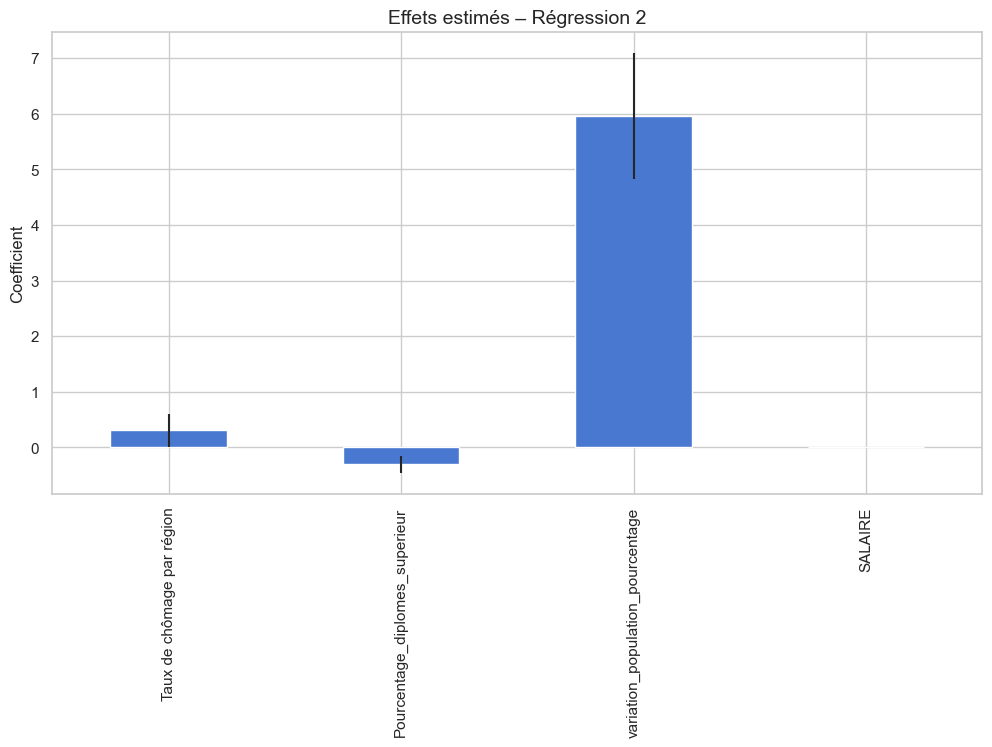

In [24]:
coef2 = results2.params.drop("const")
err2 = results2.bse.drop("const")

coef2.plot(kind="bar", yerr=1.96 * err2)
plt.title("Effets estimés – Régression 2")
plt.ylabel("Coefficient")
plt.show()




On a un R**2 haut (
=0.648), mais potentiellement **instable**.

Egalement, le coefficient lié à salaire est très faible, mais pour autant cette variable est significative ! Cela est lié à un effet d'échelle.

<h3 style="color: #2E86C1;">3.2.1. Le problème de la multicollinéarité (Condition Number) </h3>


Tout en bas, la note [2] : « The condition number is large », *id est* nos variables explicatives se ressemblent trop.

Par exemple, une région avec des salaires élevés est souvent aussi une région avec beaucoup de diplômés. Le modèle a du mal à séparer l'impact du salaire de celui du diplôme. Cela peut inverser les signes (ce qui expliquerait pourquoi "Diplôme" est proche de 0 alors qu'on s'attendrait à un effet fortement positif). Le modèle "sait" prédire, mais il ne "comprend" pas vraiment qui fait quoi.

On va donc vérifier la corrélation entre nos variables explicatives avant de faire la régression. Cela confirmera si "salaire" et "diplôme" disent la même chose.

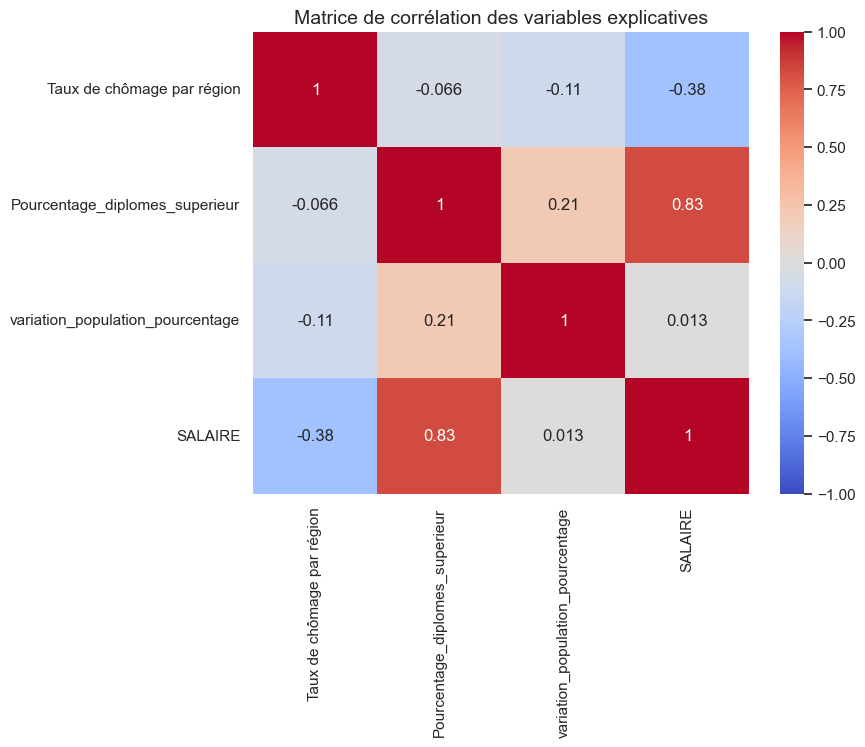

In [25]:
# On reprend nos features
features = [
    'Taux de chômage par région',
    'Pourcentage_diplomes_superieur',
    'variation_population_pourcentage',
    'SALAIRE'
]

# Calcul de la matrice
corr_matrix = regression2[features].corr()

# Affichage avec une Heatmap (carte de chaleur)
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Matrice de corrélation des variables explicatives")
plt.show()

La coefficient de corrélation entre `Pourcentage_diplomes_superieur` et `SALAIRE` vaut 0.71.

En statistiques, une corrélation de 0.71 est considérée comme très forte. Cela signifie que ces deux variables racontent quasiment la même histoire : les zones où les gens sont diplômés sont aussi les zones où les salaires sont élevés.

Pour le modèle (OLS classique), il n'arrive pas à savoir si la création d'entreprise est due au diplôme ou à l'argent.

<h2 style="color: #2E86C1;">3.3. Méthode Lasso pour déterminer les variables à conserver</h2>

La forte corrélation entre le salaire et le niveau de diplôme suggère une multicolinéarité potentielle. Un modèle Lasso est utilisé afin d’identifier la variable la plus informative, en pénalisant les variables redondantes.

In [32]:
# On standardise les variables

features = [
    'Taux de chômage par région', 
    'Pourcentage_diplomes_superieur',     
    'variation_population_pourcentage', 
    'SALAIRE'
]

X = regression2[features]
y = regression2['creations_per_1000']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Régression LASSO

lasso = LassoCV(cv=5, random_state=0)
lasso.fit(X_scaled, y)


LassoCV(cv=5, random_state=0)

In [28]:
# Visualisation des coefficients

lasso_coef = pd.Series(lasso.coef_, index=features)
print(lasso_coef)


Taux de chômage par région         -0.000000
Pourcentage_diplomes_superieur      0.000000
variation_population_pourcentage    1.411137
SALAIRE                             2.805395
dtype: float64


Malgré une corrélation élevée entre le salaire et le niveau de diplôme, le modèle LASSO conserve l’ensemble des variables explicatives, indiquant qu’elles apportent chacune une information complémentaire pour expliquer la création d’entreprises.

<h2 style="color: #2E86C1;">3.4. Régression linéaire 3</h2>

Pourquoi avons-nous testé la variable « Chômage au carré » ? 

L'objectif était de vérifier si la relation entre le chômage et la création d'entreprises était non-linéaire (c'est-à-dire si elle formait une courbe plutôt qu'une ligne droite).

L'hypothèse économique (Effet de seuil) : Nous soupçonnions un effet ambivalent du chômage. D'un côté, un chômage très élevé peut signaler une économie locale sinistrée où le pouvoir d'achat est trop faible pour soutenir de nouvelles entreprises. De l'autre, un chômage modéré peut inciter à la création d'entreprise par nécessité (faute de trouver un emploi salarié). Ainsi l'effet marginale du chômage sur la création d'entreprises ne serait pas constant.

La traduction mathématique : En ajoutant le terme au carré, nous cherchions une forme en "U" ou en "U inversé" (cloche). Cela permet de détecter un point de bascule (un seuil de chômage) à partir duquel la tendance s'inverse.

<h1 id="conclusion" style="color:rgb(255, 255, 255); border-left: 10px solid rgb(255, 255, 255); padding-left: 15px;">Conclusion & ouverture</h1>